In [ ]:
!pip install neo4j graphdatascience --quiet
from neo4j import GraphDatabase

URI = ""
AUTH = ("","")

driver = GraphDatabase.driver(URI, auth=AUTH)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 14.4 MB/s eta 0:00:00


In [ ]:
#per eliminare eventuali database già creati durante la sessione
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")



In [ ]:
#INSERIMENTO DATI
docenti = [
    {"id": "d1", "nome": "Alice Rossi"},
    {"id": "d2", "nome": "Bob Bianchi"},
    {"id": "d3", "nome": "Carol Verdi"}
]

with driver.session() as session:
    for docente in docenti:
        session.run("""
            MERGE (d:Docente {id: $id})
            SET d.nome = $nome
        """, id=docente["id"], nome=docente["nome"])

In [ ]:
argomenti = [
    {"id": "a1", "nome": "Matematica Base"},
    {"id": "a2", "nome": "Algebra"},
    {"id": "a3", "nome": "Calcolo"},
    {"id": "a4", "nome": "Python Basics"},
    {"id": "a5", "nome": "Data Science"},
    {"id": "a6", "nome": "Machine Learning"}
]

with driver.session() as session:
    for arg in argomenti:
        session.run("""
            MERGE (a:Argomento {id: $id})
            SET a.nome = $nome
        """, id=arg["id"], nome=arg["nome"])



In [ ]:
prerequisiti = [
    {"from": "a1", "to": "a2"},
    {"from": "a2", "to": "a3"},
    {"from": "a4", "to": "a5"},
    {"from": "a5", "to": "a6"}
]

with driver.session() as session:
    for prep in prerequisiti:
        session.run("""
            MATCH (a1:Argomento {id: $from})
            MATCH (a2:Argomento {id: $to})
            MERGE (a1)-[:PROPEDEUTICO_A]->(a2)
        """, **prep)



In [ ]:

corsi = [
    {"id": "c1", "titolo": "Introduzione a Python", "livello": "Principiante", "durata": 20, "categoria": "Programmazione"},
    {"id": "c2", "titolo": "Data Science 101", "livello": "Intermedio", "durata": 40, "categoria": "Data Science"},
    {"id": "c3", "titolo": "Machine Learning Avanzato", "livello": "Avanzato", "durata": 60, "categoria": "AI"},
    {"id": "c4", "titolo": "Matematica per l'IA", "livello": "Intermedio", "durata": 30, "categoria": "Matematica"},
    {"id": "c5", "titolo": "Calcolo Differenziale", "livello": "Intermedio", "durata": 25, "categoria": "Matematica"}
]

with driver.session() as session:
    for corso in corsi:
        session.run("""
            MERGE (c:Corso {id: $id})
            SET c.titolo = $titolo, c.livello = $livello,
                c.durata = $durata, c.categoria = $categoria
        """, **corso)



In [ ]:
corsi_argomenti = [
    {"corso": "c1", "argomento": "a4"},
    {"corso": "c2", "argomento": "a4"},
    {"corso": "c2", "argomento": "a5"},
    {"corso": "c3", "argomento": "a5"},
    {"corso": "c3", "argomento": "a6"},
    {"corso": "c4", "argomento": "a1"},
    {"corso": "c4", "argomento": "a2"},
    {"corso": "c5", "argomento": "a2"},
    {"corso": "c5", "argomento": "a3"}
]

with driver.session() as session:
    for ca in corsi_argomenti:
        session.run("""
            MATCH (c:Corso {id: $corso})
            MATCH (a:Argomento {id: $argomento})
            MERGE (c)-[:TRATTA]->(a)
        """, **ca)


In [ ]:
docenti_corsi = [
    {"docente": "d1", "corso": "c1"},
    {"docente": "d1", "corso": "c2"},
    {"docente": "d2", "corso": "c3"},
    {"docente": "d2", "corso": "c4"},
    {"docente": "d3", "corso": "c5"}
]

with driver.session() as session:
    for dc in docenti_corsi:
        session.run("""
            MATCH (d:Docente {id: $docente})
            MATCH (c:Corso {id: $corso})
            MERGE (d)-[:TIENE]->(c)
        """, **dc)



In [ ]:
studenti = [
    {"id": "s1", "nome": "Marco Neri"},
    {"id": "s2", "nome": "Lucia Rossi"},
    {"id": "s3", "nome": "Giovanni Blu"},
    {"id": "s4", "nome": "Sofia Gialli"},
    {"id": "s5", "nome": "Andrea Arancio"}
]

with driver.session() as session:
    for studente in studenti:
        session.run("""
            MERGE (s:Studente {id: $id})
            SET s.nome = $nome
        """, **studente)

In [ ]:

iscrizioni = [
    {"studente": "s1", "corso": "c1"},
    {"studente": "s1", "corso": "c2"},
    {"studente": "s2", "corso": "c1"},
    {"studente": "s2", "corso": "c2"},
    {"studente": "s3", "corso": "c4"},
    {"studente": "s3", "corso": "c5"},
    {"studente": "s4", "corso": "c1"},
    {"studente": "s4", "corso": "c3"},
    {"studente": "s5", "corso": "c3"}
]

with driver.session() as session:
    for iscrizione in iscrizioni:
        session.run("""
            MATCH (s:Studente {id: $studente})
            MATCH (c:Corso {id: $corso})
            MERGE (s)-[:ISCRITTO_A]->(c)
        """, **iscrizione)


In [ ]:

certificati_dati = [
    {"id": "cert1", "studente": "s1", "corso": "c1"},
    {"id": "cert2", "studente": "s1", "corso": "c2"},
    {"id": "cert3", "studente": "s2", "corso": "c1"},
    {"id": "cert4", "studente": "s3", "corso": "c5"}
]

with driver.session() as session:
    for cert in certificati_dati:
        session.run("""
            MERGE (cert:Certificato {id: $id})
            MERGE (s:Studente {id: $studente})
            MERGE (c:Corso {id: $corso})
            MERGE (s)-[:HA_CONSEGUITO]->(cert)
            MERGE (cert)-[:ACCREDITA]->(c)
        """, **cert)



In [ ]:
#PRIMA QUERY SOTTOGRAFO
dag, result = gds.graph.project(
    "dagArgomenti",
    "Argomento",
    {
        "PROPEDEUTICO_A": {
            "orientation": "NATURAL"
        }
    }
)

print(result)


nodeProjection            {'Argomento': {'properties': {}, 'label': 'Arg...
relationshipProjection    {'PROPEDEUTICO_A': {'orientation': 'NATURAL', ...
graphName                                                      dagArgomenti
nodeCount                                                                 6
relationshipCount                                                         4
projectMillis                                                            13
Name: 0, dtype: object


In [ ]:
#SCELGO UN NODO INIZIALE
query = """
MATCH (a:Argomento {id:'a4'})
RETURN id(a) AS id
"""

with driver.session() as session:

    result = session.run(query)

    nodo_partenza = result.single()["id"]

print("Nodo iniziale DFS:", nodo_partenza)


Nodo iniziale DFS: 6


In [ ]:
#DFS
query = """
CALL gds.dfs.stream(
    'dagArgomenti',
    {
        sourceNode: $start
    }
)
YIELD path
RETURN path
"""

with driver.session() as session:

    result = session.run(
        query,
        start=nodo_partenza
    )

    for record in result:
        print(record["path"])


<Path start=<Node element_id='4:45d0b1f8-562a-4dc4-9d67-6511e897ad19:6' labels=frozenset({'Argomento'}) properties={'nome': 'Python Basics', 'id': 'a4'}> end=<Node element_id='4:45d0b1f8-562a-4dc4-9d67-6511e897ad19:8' labels=frozenset({'Argomento'}) properties={'nome': 'Machine Learning', 'id': 'a6'}> size=2>


In [ ]:
#argomenti raggiunti
query = """
CALL gds.dfs.stream(
    'dagArgomenti',
    {
        sourceNode: $start
    }
)
YIELD path

UNWIND nodes(path) AS n

RETURN DISTINCT n.nome AS argomento
"""

with driver.session() as session:

    result = session.run(
        query,
        start=nodo_partenza
    )

    argomenti_trovati = []

    for record in result:
        argomenti_trovati.append(record["argomento"])


print("Argomenti raggiunti:")
for a in argomenti_trovati:
    print("-", a)


Argomenti raggiunti:
- Python Basics
- Data Science
- Machine Learning


In [ ]:
#corsi collegati
query = """
MATCH (c:Corso)-[:TRATTA]->(a:Argomento)

WHERE a.nome IN $argomenti

RETURN DISTINCT
       c.titolo AS corso,
       a.nome AS argomento

ORDER BY corso
"""

with driver.session() as session:

    result = session.run(
        query,
        argomenti=argomenti_trovati
    )

    print("Corsi collegati:\n")

    for record in result:

        print(
            record["corso"],
            "->",
            record["argomento"]
        )


Corsi collegati:

Data Science 101 -> Python Basics
Data Science 101 -> Data Science
Introduzione a Python -> Python Basics
Machine Learning Avanzato -> Data Science
Machine Learning Avanzato -> Machine Learning


In [ ]:
#ORDINAMENTO TOPOLOGICO
query = """
CALL gds.dag.topologicalSort.stream(
    'dagArgomenti'
)
YIELD nodeId

MATCH (a:Argomento)
WHERE id(a)=nodeId

RETURN a.nome AS argomento
"""

with driver.session() as session:

    result = session.run(query)

    print("Ordinamento topologico degli argomenti:\n")

    for record in result:
        print("-", record["argomento"])


Ordinamento topologico degli argomenti:

- Python Basics
- Matematica Base
- Data Science
- Algebra
- Machine Learning
- Calcolo


In [ ]:
#PROIEZIONE MONOPARTITA SU STUDENTE
studenti_proj, result = gds.graph.project.cypher(
    "studentiProiettati",

    """
    MATCH (s:Studente)
    RETURN id(s) AS id, labels(s) AS labels
    """,

    """
    MATCH (s1:Studente)-[:ISCRITTO_A]->(:Corso)-[:TRATTA]->(a:Argomento)
    MATCH (s2:Studente)-[:ISCRITTO_A]->(:Corso)-[:TRATTA]->(a)

    WHERE id(s1) < id(s2)

    RETURN id(s1) AS source,
           id(s2) AS target,
           'CONDIVIDE_ARGOMENTO' AS type
    """
)

print(result)


nodeQuery            MATCH (s:Studente)\n    RETURN id(s) AS id, la...
relationshipQuery    MATCH (s1:Studente)-[:ISCRITTO_A]->(:Corso)-[:...
graphName                                           studentiProiettati
nodeCount                                                            5
relationshipCount                                                   15
projectMillis                                                       45
Name: 0, dtype: object


In [ ]:
#LOUVAIN
query = """
CALL gds.louvain.stream(
    'studentiProiettati'
)
YIELD nodeId, communityId

MATCH (s:Studente)
WHERE id(s)=nodeId

RETURN
       s.nome AS studente,
       communityId AS comunita
ORDER BY comunita
"""

with driver.session() as session:

    result = session.run(query)

    print("Comunità di studenti:\n")

    for record in result:
        print(
            record["studente"],
            "-> comunità",
            record["comunita"]
        )


Comunità di studenti:

Giovanni Blu -> comunità 2
Marco Neri -> comunità 4
Lucia Rossi -> comunità 4
Sofia Gialli -> comunità 4
Andrea Arancio -> comunità 4


/tmp/ipykernel_2679/4196658594.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_communities))


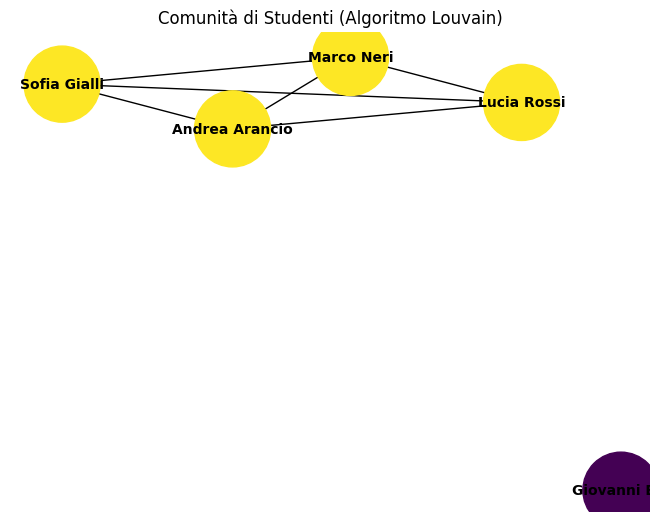

In [ ]:
#VISUALIZZAZIONE LOUVAIN
import networkx as nx
import matplotlib.pyplot as plt

G_louvain = nx.Graph()

query_communities = """
CALL gds.louvain.stream('studentiProiettati')
YIELD nodeId, communityId
MATCH (s:Studente) WHERE id(s) = nodeId
RETURN s.nome AS studentName, communityId
"""

student_communities = {}
with driver.session() as session:
    result_comm = session.run(query_communities)
    for record in result_comm:
        student_communities[record["studentName"]] = record["communityId"]
        G_louvain.add_node(record["studentName"])

query_edges = """
MATCH (s1:Studente)-[:ISCRITTO_A]->(:Corso)-[:TRATTA]->(a:Argomento)
MATCH (s2:Studente)-[:ISCRITTO_A]->(:Corso)-[:TRATTA]->(a)
WHERE id(s1) < id(s2)
RETURN s1.nome AS sourceName, s2.nome AS targetName
"""

with driver.session() as session:
    result_edges = session.run(query_edges)
    for record in result_edges:
        G_louvain.add_edge(record["sourceName"], record["targetName"])



unique_communities = list(set(student_communities.values()))
colors = plt.cm.get_cmap('viridis', len(unique_communities))

node_colors = [
    colors(unique_communities.index(student_communities.get(node, -1)))
    for node in G_louvain.nodes()
]

nx.draw(
    G_louvain,
    with_labels=True,
    node_color=node_colors,
    node_size=3000,
    font_size=10,
    font_weight='bold',
    arrows=False
)

plt.title("Comunità di Studenti (Algoritmo Louvain)")
plt.show()

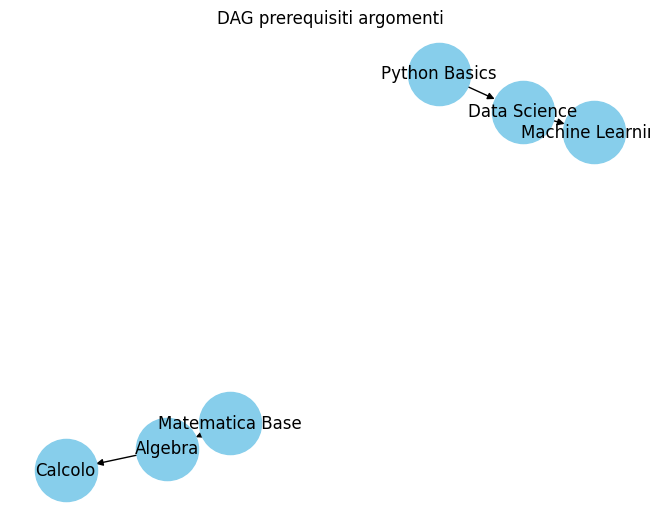

In [ ]:

#VISUALIZZAZIONI DFS
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

query = """
MATCH (a1:Argomento)-[:PROPEDEUTICO_A]->(a2:Argomento)
RETURN a1.nome AS a1, a2.nome AS a2
"""

with driver.session() as session:
    result = session.run(query)

    for r in result:
        G.add_edge(r["a1"], r["a2"])


nx.draw(
    G,
    with_labels=True,
    node_color="skyblue",
    node_size=2000,
    arrows=True
)

plt.title("DAG prerequisiti argomenti")
plt.show()


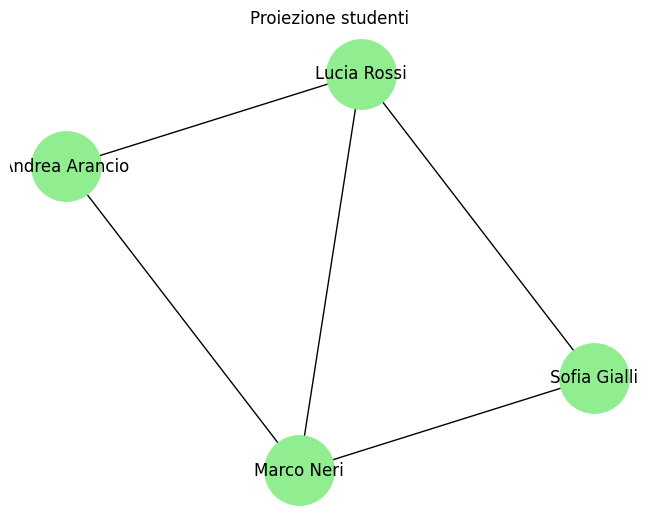

In [ ]:
#VISUALIZZAZIONI PROIEZIONE
G = nx.Graph()

query = """
MATCH (s1:Studente)-[:ISCRITTO_A]->(c:Corso)-[:TRATTA]->(a:Argomento),
      (s2:Studente)-[:ISCRITTO_A]->(c2:Corso)-[:TRATTA]->(a)

WHERE id(s1)<id(s2)

RETURN s1.nome AS s1, s2.nome AS s2
"""

with driver.session() as session:
    result = session.run(query)

    for r in result:
        G.add_edge(r["s1"], r["s2"])


nx.draw(
    G,
    with_labels=True,
    node_color="lightgreen",
    node_size=2500
)

plt.title("Proiezione studenti")
plt.show()


In [ ]:
#chiusura
driver.close()